In [2]:
from pathlib import Path
import sys
import numpy as np

# Add mast3r repo to path so internal absolute imports work
MAST3R_REPO_PATH = Path("/home/hugues/Documents/mee-deepreefmap/mast3r")
if str(MAST3R_REPO_PATH) not in sys.path:
    sys.path.insert(0, str(MAST3R_REPO_PATH))

# dust3r is nested inside the mast3r submodule
DUST3R_PATH = MAST3R_REPO_PATH / "dust3r"
if str(DUST3R_PATH) not in sys.path:
    sys.path.insert(0, str(DUST3R_PATH))

# Add src to path for local imports
SRC_PATH = Path("/home/hugues/Documents/mee-deepreefmap/src")
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [3]:
"""Configure input/output paths.

Change these to point to your forward and backward reconstruction outputs.
"""
output_fw_dir = Path(
    "/home/hugues/Documents/mee-deepreefmap/output/israel-eilat/2024_Sunrise_fw_leg"
)
output_bw_dir = Path(
    "/home/hugues/Documents/mee-deepreefmap/output/israel-eilat/2024_Sunrise_bw_leg"
)
colmap_workdir = output_fw_dir.parent / "colmap_mast3r"
colmap_workdir.mkdir(parents=True, exist_ok=True)
print(f"COLMAP workdir: {colmap_workdir}")

COLMAP workdir: /home/hugues/Documents/mee-deepreefmap/output/israel-eilat/colmap_mast3r


In [30]:
"""Load reconstruction outputs.

poses.npy         → [N, 4, 4] C2W poses
intrinsics.npy    → [N, 6] EUCM intrinsics (fx, fy, cx, cy, alpha, beta)
frames/*.jpg      → N frame images
"""
poses_fw = np.load(output_fw_dir / "poses.npy")
intrinsics_fw = np.load(output_fw_dir / "intrinsics.npy")
frames_fw = sorted(output_fw_dir.glob("frames/*.jpg"), key=lambda p: int(p.stem))

poses_bw = np.load(output_bw_dir / "poses.npy")
intrinsics_bw = np.load(output_bw_dir / "intrinsics.npy")
frames_bw = sorted(output_bw_dir.glob("frames/*.jpg"), key=lambda p: int(p.stem))

N_fw = len(frames_fw)
N_bw = len(frames_bw)
print(f"Forward:  {N_fw} frames, poses {poses_fw.shape}")
print(f"Backward: {N_bw} frames, poses {poses_bw.shape}")

Forward:  1160 frames, poses (1160, 4, 4)
Backward: 890 frames, poses (890, 4, 4)


In [31]:
"""Undistort all frames using EUCM → pinhole rectification.

GoPro Hero 10 uses a fisheye lens modeled by EUCM (Enhanced Unified Camera
Model) with params [fx, fy, cx, cy, alpha, beta]. COLMAP needs undistorted
images for PINHOLE camera model to work correctly.

The rectified images use [fx, fy, cx, cy] as pinhole intrinsics.
"""
import torch as _torch
from PIL import Image as _PIL
from sfm.inverse_warp import rectify_eucm
from tqdm import tqdm as _tqdm

rect_dir = colmap_workdir / "images_rect"
rect_dir.mkdir(exist_ok=True)

# Use mean intrinsics for rectification (they're nearly identical per frame)
_intr_mean = np.mean(intrinsics_fw, axis=0).astype(np.float32)  # [fx,fy,cx,cy,alpha,beta]
_intr_t = _torch.from_numpy(_intr_mean)


def _rectify_and_save(src_path, dst_path):
    if dst_path.exists():
        return
    pil = _PIL.open(src_path).convert("RGB")
    arr = np.array(pil).astype(np.float32) / 255.0
    H, W = arr.shape[:2]
    img_t = _torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0)  # [1, 3, H, W]
    mask_t = _torch.ones(1, 1, H, W)
    depth_t = _torch.ones(1, 1, H, W)
    rect_img, _, _ = rectify_eucm(img_t, mask_t, depth_t, _intr_t)
    rect_uint8 = (rect_img.transpose(1, 2, 0).clip(0, 1) * 255).astype(np.uint8)
    _PIL.fromarray(rect_uint8).save(dst_path, quality=95)


# Rectify all frames (indexed by position so rect_frames_fw[i] == rectified frames_fw[i])
rect_frames_fw = []
for p in _tqdm(frames_fw, desc="Rectifying fw"):
    dst = rect_dir / f"fwd_{int(p.stem):06d}.jpg"
    _rectify_and_save(p, dst)
    rect_frames_fw.append(dst)

rect_frames_bw = []
for p in _tqdm(frames_bw, desc="Rectifying bw"):
    dst = rect_dir / f"bwd_{int(p.stem):06d}.jpg"
    _rectify_and_save(p, dst)
    rect_frames_bw.append(dst)

# Pinhole intrinsics after rectification (just fx, fy, cx, cy — distortion removed)
pinhole_intr = _intr_mean[:4]
print(f"Rectified {len(rect_frames_fw)} fw + {len(rect_frames_bw)} bw frames → {rect_dir}")
print(
    f"Pinhole intrinsics: fx={pinhole_intr[0]:.1f} fy={pinhole_intr[1]:.1f} "
    f"cx={pinhole_intr[2]:.1f} cy={pinhole_intr[3]:.1f}"
)

Rectifying bw: 100%|██████████| 890/890 [00:00<00:00, 95610.75it/s]

Rectified 1160 fw + 890 bw frames → /home/hugues/Documents/mee-deepreefmap/output/israel-eilat/colmap_mast3r/images_rect
Pinhole intrinsics: fx=365.4 fy=383.1 cx=319.8 cy=191.8


In [32]:
"""Load MASt3R model."""
import torch
from mast3r.model import AsymmetricMASt3R

model_name = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AsymmetricMASt3R.from_pretrained(model_name).to(device)
model.eval()
print(f"MASt3R loaded on {device}")

MASt3R loaded on cuda


In [33]:
"""Extract DINOv2 global descriptors for cross-view pair selection."""
import numpy as _np
import torchvision.transforms as _T
from PIL import Image as _PIL
from tqdm import tqdm as _tqdm

_device = "cuda" if torch.cuda.is_available() else "cpu"
_dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14").to(_device).eval()
_transform = _T.Compose([
    _T.Resize(224, interpolation=_T.InterpolationMode.BICUBIC),
    _T.CenterCrop(224),
    _T.ToTensor(),
    _T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


@torch.no_grad()
def _extract(paths, batch_size=32):
    descs = []
    for i in _tqdm(range(0, len(paths), batch_size), desc="DINOv2"):
        batch = torch.stack([
            _transform(_PIL.open(p).convert("RGB")) for p in paths[i : i + batch_size]
        ]).to(_device)
        descs.append(_dino(batch))
    return torch.cat(descs).cpu().numpy()


descs_fw = _extract(rect_frames_fw)
descs_bw = _extract(rect_frames_bw)
print(f"DINOv2 descriptors: fw {descs_fw.shape}, bw {descs_bw.shape}")

Using cache found in /home/hugues/.cache/torch/hub/facebookresearch_dinov2_main
DINOv2: 100%|██████████| 28/28 [00:11<00:00,  2.51it/s]

DINOv2 descriptors: fw (1160, 384), bw (890, 384)


Cross pairs (fw↔bw): 387
Sequential fw pairs: 921 (logwin offsets [5, 10, 20, 40])
Sequential bw pairs: 705 (logwin offsets [5, 10, 20, 40])


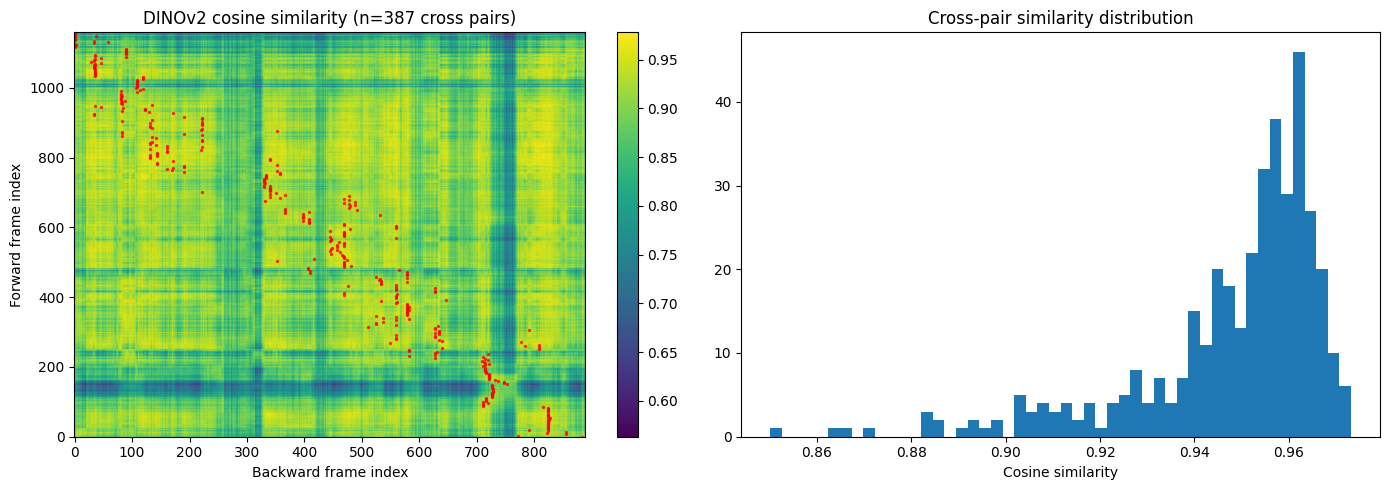

In [34]:
"""Select fw↔bw pairs using DINOv2 similarity + temporal prior.

Also select within-pass sequential pairs for COLMAP's sequential
connectivity. The combined pair list gives COLMAP both:
  - Sequential edges (odometry-like) within each pass
  - Cross-pass edges (loop closures) between fw and bw
"""
import matplotlib.pyplot as _plt

# ── Cross-pass pairs (fw ↔ bw) ──────────────────────────────────────
_norms_fw = np.linalg.norm(descs_fw, axis=1, keepdims=True)
_norms_bw = np.linalg.norm(descs_bw, axis=1, keepdims=True)
sim = (descs_fw / _norms_fw) @ (descs_bw / _norms_bw).T

FW_STEP = 3  # one cross pair every 3 fw frames (denser sampling)
WINDOW = 150  # search ±150 bw frames around time-prior center
SIM_THRESH = 0.85  # lower threshold to get more cross-pass pairs

cross_pairs_local = []  # (fw_local_idx, bw_local_idx)
for i in range(0, N_fw, FW_STEP):
    j_center = int(round((1 - i / max(N_fw - 1, 1)) * (N_bw - 1)))
    j_lo = max(0, j_center - WINDOW)
    j_hi = min(N_bw, j_center + WINDOW + 1)
    j_best = j_lo + int(np.argmax(sim[i, j_lo:j_hi]))
    if sim[i, j_best] >= SIM_THRESH:
        cross_pairs_local.append((i, j_best))

# ── Sequential pairs (logwin: connect at distances 5, 10, 20, 40) ──
# Close pairs give robust matches; distant pairs give parallax for triangulation.
# COLMAP needs wide-baseline pairs to bootstrap initialization.
LOGWIN_OFFSETS = [5, 10, 20, 40]

seq_fw_local = set()
for i in range(0, N_fw, 5):
    for off in LOGWIN_OFFSETS:
        j = min(i + off, N_fw - 1)
        if i != j:
            seq_fw_local.add((min(i, j), max(i, j)))
seq_fw_local = sorted(seq_fw_local)

seq_bw_local = set()
for i in range(0, N_bw, 5):
    for off in LOGWIN_OFFSETS:
        j = min(i + off, N_bw - 1)
        if i != j:
            seq_bw_local.add((min(i, j), max(i, j)))
seq_bw_local = sorted(seq_bw_local)

print(f"Cross pairs (fw↔bw): {len(cross_pairs_local)}")
print(f"Sequential fw pairs: {len(seq_fw_local)} (logwin offsets {LOGWIN_OFFSETS})")
print(f"Sequential bw pairs: {len(seq_bw_local)} (logwin offsets {LOGWIN_OFFSETS})")

# ── Visualisation ───────────────────────────────────────────────────
_fig, (_ax1, _ax2) = _plt.subplots(1, 2, figsize=(14, 5))
_ax1.imshow(sim, aspect="auto", origin="lower", cmap="viridis")
if cross_pairs_local:
    _fi_list, _bi_list = zip(*cross_pairs_local)
    _ax1.scatter(_bi_list, _fi_list, s=2, c="red", alpha=0.7)
_ax1.set_xlabel("Backward frame index")
_ax1.set_ylabel("Forward frame index")
_ax1.set_title(f"DINOv2 cosine similarity (n={len(cross_pairs_local)} cross pairs)")
_plt.colorbar(_ax1.images[0], ax=_ax1)

_sims = [float(sim[i, j]) for i, j in cross_pairs_local]
_ax2.hist(_sims, bins=50)
_ax2.set_xlabel("Cosine similarity")
_ax2.set_title("Cross-pair similarity distribution")
_plt.tight_layout()
_plt.show()

In [56]:
"""Create COLMAP database with cameras + images.

Global index scheme:
  fwd frame i  → global index i        → name "fwd_{i:06d}.jpg"
  bwd frame j  → global index N_fw + j  → name "bwd_{j:06d}.jpg"

Images are RECTIFIED (pinhole undistorted). Camera model: PINHOLE [fx, fy, cx, cy].
MASt3R runs on original fisheye images for best match quality, then keypoints
are transformed from EUCM fisheye → pinhole coordinates before DB export.
"""
import sqlite3
import os
from PIL import Image as _PIL
from scipy.spatial.transform import Rotation as _Rot

# ── Collect used frame indices ────────────────────────────────────────
used_fw_indices = set()
used_bw_indices = set()

for fi, bi in cross_pairs_local:
    used_fw_indices.add(fi)
    used_bw_indices.add(bi)
for fi, fj in seq_fw_local:
    used_fw_indices.add(fi)
    used_fw_indices.add(fj)
for bi, bj in seq_bw_local:
    used_bw_indices.add(bi)
    used_bw_indices.add(bj)

used_fw_indices = sorted(used_fw_indices)
used_bw_indices = sorted(used_bw_indices)
print(f"Unique frames: {len(used_fw_indices)} fw + {len(used_bw_indices)} bw")

# ── Use rectified images (already created by lEQa cell) ──────────────
img_dir = rect_dir  # images_rect/ with fwd_*.jpg and bwd_*.jpg
print(f"img_dir: {img_dir}")

# ── EUCM → pinhole coordinate transform ──────────────────────────────
# MASt3R keypoints are in original fisheye (EUCM) pixel space.
# We need to transform them to rectified (pinhole) pixel space for COLMAP.
#
# EUCM unproject: pixel (u,v) → 3D ray direction (mx, my, mz)
#   mx = (u - cx) / fx
#   my = (v - cy) / fy
#   r² = mx² + my²
#   mz = (1 - β·α²·r²) / (α·√(1 - (2α-1)·β·r²) + (1-α))
#
# Pinhole project: 3D ray → rectified pixel (u', v')
#   u' = fx · mx/mz + cx
#   v' = fy · my/mz + cy
_alpha_eucm = float(_intr_mean[4])
_beta_eucm = float(_intr_mean[5])
_fx = float(_intr_mean[0])
_fy = float(_intr_mean[1])
_cx = float(_intr_mean[2])
_cy = float(_intr_mean[3])
print(f"EUCM params: alpha={_alpha_eucm:.4f} beta={_beta_eucm:.4f}")
print(f"Pinhole intrinsics: fx={_fx:.1f} fy={_fy:.1f} cx={_cx:.1f} cy={_cy:.1f}")


def eucm_to_pinhole(x_orig, y_orig):
    """Transform pixel coords from EUCM (original fisheye) to pinhole (rectified).

    Args:
        x_orig, y_orig: arrays of pixel coords in original fisheye image
    Returns:
        x_rect, y_rect: arrays of pixel coords in rectified pinhole image
    """
    mx = (x_orig - _cx) / _fx
    my = (y_orig - _cy) / _fy
    r2 = mx**2 + my**2
    # EUCM validity: 1 - (2α-1)·β·r² > 0
    inner = 1.0 - (2.0 * _alpha_eucm - 1.0) * _beta_eucm * r2
    inner = np.clip(inner, 1e-8, None)  # clamp for numerical safety
    mz = (1.0 - _beta_eucm * _alpha_eucm**2 * r2) / (
        _alpha_eucm * np.sqrt(inner) + (1.0 - _alpha_eucm)
    )
    # Pinhole project
    x_rect = _fx * mx / mz + _cx
    y_rect = _fy * my / mz + _cy
    return x_rect, y_rect


# ── Build COLMAP database ─────────────────────────────────────────────
db_path = colmap_workdir / "colmap.db"
if db_path.exists():
    db_path.unlink()

_con = sqlite3.connect(str(db_path))
cur = _con.cursor()
cur.executescript("""
    CREATE TABLE IF NOT EXISTS cameras (
        camera_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
        model INTEGER NOT NULL,
        width INTEGER NOT NULL,
        height INTEGER NOT NULL,
        params BLOB,
        prior_focal_length INTEGER NOT NULL);
    CREATE TABLE IF NOT EXISTS images (
        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
        name TEXT NOT NULL UNIQUE,
        camera_id INTEGER NOT NULL,
        prior_qw REAL, prior_qx REAL, prior_qy REAL, prior_qz REAL,
        prior_tx REAL, prior_ty REAL, prior_tz REAL);
    CREATE TABLE IF NOT EXISTS keypoints (
        image_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL,
        cols INTEGER NOT NULL,
        data BLOB);
    CREATE TABLE IF NOT EXISTS matches (
        pair_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL,
        cols INTEGER NOT NULL,
        data BLOB);
    CREATE TABLE IF NOT EXISTS two_view_geometries (
        pair_id INTEGER PRIMARY KEY NOT NULL,
        rows INTEGER NOT NULL,
        cols INTEGER NOT NULL,
        data BLOB,
        config INTEGER NOT NULL,
        F BLOB, E BLOB, H BLOB,
        qvec BLOB, tvec BLOB);
""")
_con.commit()

# Camera: PINHOLE (model_id=1) — params [fx, fy, cx, cy]
_pil_sample = _PIL.open(frames_fw[0])
W_orig, H_orig = _pil_sample.size  # same resolution for rectified images
_cam_params = np.array([_fx, _fy, _cx, _cy], dtype=np.float64)
cur.execute(
    "INSERT INTO cameras (model, width, height, params, prior_focal_length) VALUES (?,?,?,?,?)",
    (1, W_orig, H_orig, _cam_params.tobytes(), 1),
)
_con.commit()
camera_id = cur.lastrowid
print(
    f"Camera {camera_id}: PINHOLE {W_orig}x{H_orig} fx={_fx:.1f} fy={_fy:.1f} cx={_cx:.1f} cy={_cy:.1f}"
)

# Images with prior poses (C2W → W2C for COLMAP convention)
global_to_colmap_imid = {}


def _add_image(name, global_idx, c2w):
    w2c = np.linalg.inv(c2w)
    R_mat = w2c[:3, :3]
    t_vec = w2c[:3, 3]
    qxyz = _Rot.from_matrix(R_mat).as_quat()  # [x, y, z, w]
    qvec = [float(qxyz[3]), float(qxyz[0]), float(qxyz[1]), float(qxyz[2])]  # COLMAP [w,x,y,z]
    cur.execute(
        "INSERT INTO images (name, camera_id, prior_qw, prior_qx, prior_qy, prior_qz, "
        "prior_tx, prior_ty, prior_tz) VALUES (?,?,?,?,?,?,?,?,?)",
        (name, camera_id, *qvec, *t_vec.tolist()),
    )
    _con.commit()
    global_to_colmap_imid[global_idx] = cur.lastrowid


for fi in used_fw_indices:
    _add_image(f"fwd_{fi:06d}.jpg", fi, poses_fw[fi])
for bi in used_bw_indices:
    _add_image(f"bwd_{bi:06d}.jpg", N_fw + bi, poses_bw[bi])

print(f"Registered {len(global_to_colmap_imid)} images in COLMAP DB")
_con.close()

# ── Build pair list (global indices) for MASt3R matching ─────────────
all_pairs_global = []

for fi, bi in cross_pairs_local:
    all_pairs_global.append((fi, N_fw + bi))
for fi, fj in seq_fw_local:
    if fi != fj:
        all_pairs_global.append((fi, fj))
for bi, bj in seq_bw_local:
    if bi != bj:
        all_pairs_global.append((N_fw + bi, N_fw + bj))

all_pairs_global = list(set((min(a, b), max(a, b)) for a, b in all_pairs_global))
print(f"Total unique pairs for MASt3R matching: {len(all_pairs_global)}")

Unique frames: 542 fw + 272 bw
img_dir: /home/hugues/Documents/mee-deepreefmap/output/israel-eilat/colmap_mast3r/images_rect
EUCM params: alpha=-0.6000 beta=0.9150
Pinhole intrinsics: fx=365.4 fy=383.1 cx=319.8 cy=191.8
Camera 1: PINHOLE 1280x768 fx=365.4 fy=383.1 cx=319.8 cy=191.8
Registered 814 images in COLMAP DB
Total unique pairs for MASt3R matching: 2013


In [57]:
"""Run MASt3R inference on all pairs and export matches to COLMAP DB.

MASt3R runs on ORIGINAL fisheye images (best match quality — no black borders).
Keypoints are then transformed from EUCM fisheye → pinhole (rectified) coords
before export to the COLMAP DB, which uses PINHOLE camera + rectified images.
"""
import torchvision.transforms as _T
from PIL import Image as _PIL
from tqdm import tqdm as _tqdm

from dust3r.inference import inference as dust3r_inference
from mast3r.fast_nn import extract_correspondences_nonsym

TARGET_SIZE = 512
BATCH_SIZE = 4

# Sequential pairs: high confidence, coarse sampling (viewpoints nearly identical)
CONF_THR_SEQ = 1.5
SUBSAMPLE_SEQ = 8

# Cross-pass pairs: lower confidence, finer sampling (opposite-direction views)
CONF_THR_CROSS = 1.0
SUBSAMPLE_CROSS = 4

_ImgNorm = _T.Compose([_T.ToTensor(), _T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])


def _load_view(global_idx):
    """Load ORIGINAL fisheye image for MASt3R (best match quality)."""
    is_bw = global_idx >= N_fw
    local_idx = global_idx - N_fw if is_bw else global_idx
    path = frames_bw[local_idx] if is_bw else frames_fw[local_idx]
    pil = _PIL.open(path).convert("RGB")
    W, H = pil.size
    scale = TARGET_SIZE / max(H, W)
    new_H = round(H * scale / 16) * 16
    new_W = round(W * scale / 16) * 16
    pil = pil.resize((new_W, new_H), _PIL.Resampling.LANCZOS)
    return (
        dict(
            img=_ImgNorm(pil)[None],
            true_shape=np.int32([[new_H, new_W]]),
            idx=global_idx,
            instance=str(global_idx),
        ),
        new_H,
        new_W,
    )


# ── Run MASt3R on all pairs ──────────────────────────────────────────
im_keypoints = {gidx: {} for gidx in global_to_colmap_imid}
im_matches = {}
view_cache = {}
view_shape_cache = {}


def _get_view(global_idx):
    if global_idx not in view_cache:
        view, h, w = _load_view(global_idx)
        view_cache[global_idx] = view
        view_shape_cache[global_idx] = (h, w)
    return view_cache[global_idx]


for batch_start in _tqdm(range(0, len(all_pairs_global), BATCH_SIZE), desc="MASt3R inference"):
    batch_pairs = all_pairs_global[batch_start : batch_start + BATCH_SIZE]
    batch_views = [(_get_view(g0), _get_view(g1)) for g0, g1 in batch_pairs]

    result = dust3r_inference(batch_views, model, device, batch_size=BATCH_SIZE, verbose=False)
    pred1, pred2 = result["pred1"], result["pred2"]

    for k in range(pred1["pts3d"].shape[0]):
        pair_idx = batch_start + k
        if pair_idx >= len(all_pairs_global):
            break
        gidx0, gidx1 = all_pairs_global[pair_idx]

        _is_cross = (gidx0 < N_fw) != (gidx1 < N_fw)
        _subsample = SUBSAMPLE_CROSS if _is_cross else SUBSAMPLE_SEQ
        _conf_thr = CONF_THR_CROSS if _is_cross else CONF_THR_SEQ

        descs = [pred1["desc"][k], pred2["desc"][k]]
        confs = [pred1["desc_conf"][k], pred2["desc_conf"][k]]
        corres = extract_correspondences_nonsym(
            descs[0],
            descs[1],
            confs[0],
            confs[1],
            device=device,
            subsample=_subsample,
        )
        conf_mask = corres[2] >= _conf_thr
        matches_im0 = corres[0][conf_mask].cpu().numpy()
        matches_im1 = corres[1][conf_mask].cpu().numpy()

        if len(matches_im0) == 0:
            continue

        H0, W0 = batch_views[k][0]["true_shape"][0]
        H1, W1 = batch_views[k][1]["true_shape"][0]

        qx0 = matches_im0[:, 0].round().astype(np.int32).clip(0, W0 - 1)
        qy0 = matches_im0[:, 1].round().astype(np.int32).clip(0, H0 - 1)
        ravel0 = qx0 + W0 * qy0

        qx1 = matches_im1[:, 0].round().astype(np.int32).clip(0, W1 - 1)
        qy1 = matches_im1[:, 1].round().astype(np.int32).clip(0, H1 - 1)
        ravel1 = qx1 + W1 * qy1

        for r in ravel0:
            im_keypoints[gidx0][int(r)] = im_keypoints[gidx0].get(int(r), 0) + 1
        for r in ravel1:
            im_keypoints[gidx1][int(r)] = im_keypoints[gidx1].get(int(r), 0) + 1

        imidx_lo, imidx_hi = (gidx0, gidx1) if gidx0 < gidx1 else (gidx1, gidx0)
        if gidx0 < gidx1:
            colmap_matches = np.stack([ravel0, ravel1], axis=-1)
        else:
            colmap_matches = np.stack([ravel1, ravel0], axis=-1)
        colmap_matches = np.unique(colmap_matches, axis=0)

        key = (imidx_lo, imidx_hi)
        if key in im_matches:
            im_matches[key] = np.concatenate([im_matches[key], colmap_matches], axis=0)
            im_matches[key] = np.unique(im_matches[key], axis=0)
        else:
            im_matches[key] = colmap_matches

# ── Export keypoints and matches to COLMAP DB ────────────────────────
# Keypoints are transformed: MASt3R resolution (fisheye) → original res → EUCM→pinhole
_con = sqlite3.connect(str(db_path))
_cur = _con.cursor()

n_kp_total = 0
n_kp_valid = 0

for gidx, kp_dict in im_keypoints.items():
    if not kp_dict:
        continue
    if gidx not in view_shape_cache:
        continue
    mast3r_H, mast3r_W = view_shape_cache[gidx]
    # Scale from MASt3R resolution to original resolution
    sx = W_orig / mast3r_W
    sy = H_orig / mast3r_H

    kp_to_colmap_idx = {}
    kp_xy = []
    for ravel_id in sorted(kp_dict.keys()):
        y_m, x_m = divmod(int(ravel_id), mast3r_W)
        # Scale to original fisheye resolution
        x_orig = x_m * sx
        y_orig = y_m * sy
        # Transform from EUCM fisheye → pinhole (rectified) coordinates
        x_rect, y_rect = eucm_to_pinhole(x_orig, y_orig)
        n_kp_total += 1
        # Skip keypoints that fall outside rectified image bounds
        if x_rect < 0 or x_rect >= W_orig or y_rect < 0 or y_rect >= H_orig:
            continue
        n_kp_valid += 1
        kp_to_colmap_idx[ravel_id] = len(kp_xy)
        kp_xy.append([float(x_rect), float(y_rect)])

    if not kp_xy:
        continue

    kp_arr = np.array(kp_xy, dtype=np.float32)

    cimid = global_to_colmap_imid[gidx]
    _cur.execute(
        "INSERT INTO keypoints (image_id, rows, cols, data) VALUES (?,?,?,?)",
        (cimid, kp_arr.shape[0], 2, kp_arr.tobytes()),
    )
    im_keypoints[gidx]["__idx_map__"] = kp_to_colmap_idx

_con.commit()
print(
    f"Keypoints: {n_kp_valid}/{n_kp_total} valid after EUCM→pinhole transform "
    f"({n_kp_total - n_kp_valid} out of bounds)"
)


# Matches: convert ravel IDs to colmap keypoint indices
def _pair_id(id1, id2):
    lo, hi = (id1, id2) if id1 < id2 else (id2, id1)
    return lo * 2147483647 + hi


n_exported_pairs = 0
for (gidx0, gidx1), ravel_matches in im_matches.items():
    idx_map0 = im_keypoints[gidx0].get("__idx_map__")
    idx_map1 = im_keypoints[gidx1].get("__idx_map__")
    if idx_map0 is None or idx_map1 is None:
        continue

    final_matches = []
    for r0, r1 in ravel_matches:
        if int(r0) in idx_map0 and int(r1) in idx_map1:
            final_matches.append([idx_map0[int(r0)], idx_map1[int(r1)]])
    if not final_matches:
        continue

    final_matches = np.array(final_matches, dtype=np.uint32)
    cimid0 = global_to_colmap_imid[gidx0]
    cimid1 = global_to_colmap_imid[gidx1]
    pid = _pair_id(cimid0, cimid1)

    _cur.execute(
        "INSERT OR REPLACE INTO matches (pair_id, rows, cols, data) VALUES (?,?,?,?)",
        (pid, final_matches.shape[0], 2, final_matches.tobytes()),
    )
    n_exported_pairs += 1

_con.commit()
_con.close()

n_total_matches = sum(len(v) for k, v in im_matches.items() if not isinstance(k, str))
print(f"\nExported to COLMAP DB: {db_path}")
print(f"  Images with keypoints: {sum(1 for v in im_keypoints.values() if '__idx_map__' in v)}")
print(f"  Match pairs: {n_exported_pairs}")
print(f"  Total matches: {n_total_matches}")

MASt3R inference: 100%|██████████| 504/504 [08:51<00:00,  1.05s/it]


Keypoints: 7816931/7816931 valid after EUCM→pinhole transform (0 out of bounds)

Exported to COLMAP DB: /home/hugues/Documents/mee-deepreefmap/output/israel-eilat/colmap_mast3r/colmap.db
  Images with keypoints: 642
  Match pairs: 1834
  Total matches: 5710278


im_matches breakdown: 210 cross-pass | 921 seq-fw | 703 seq-bw


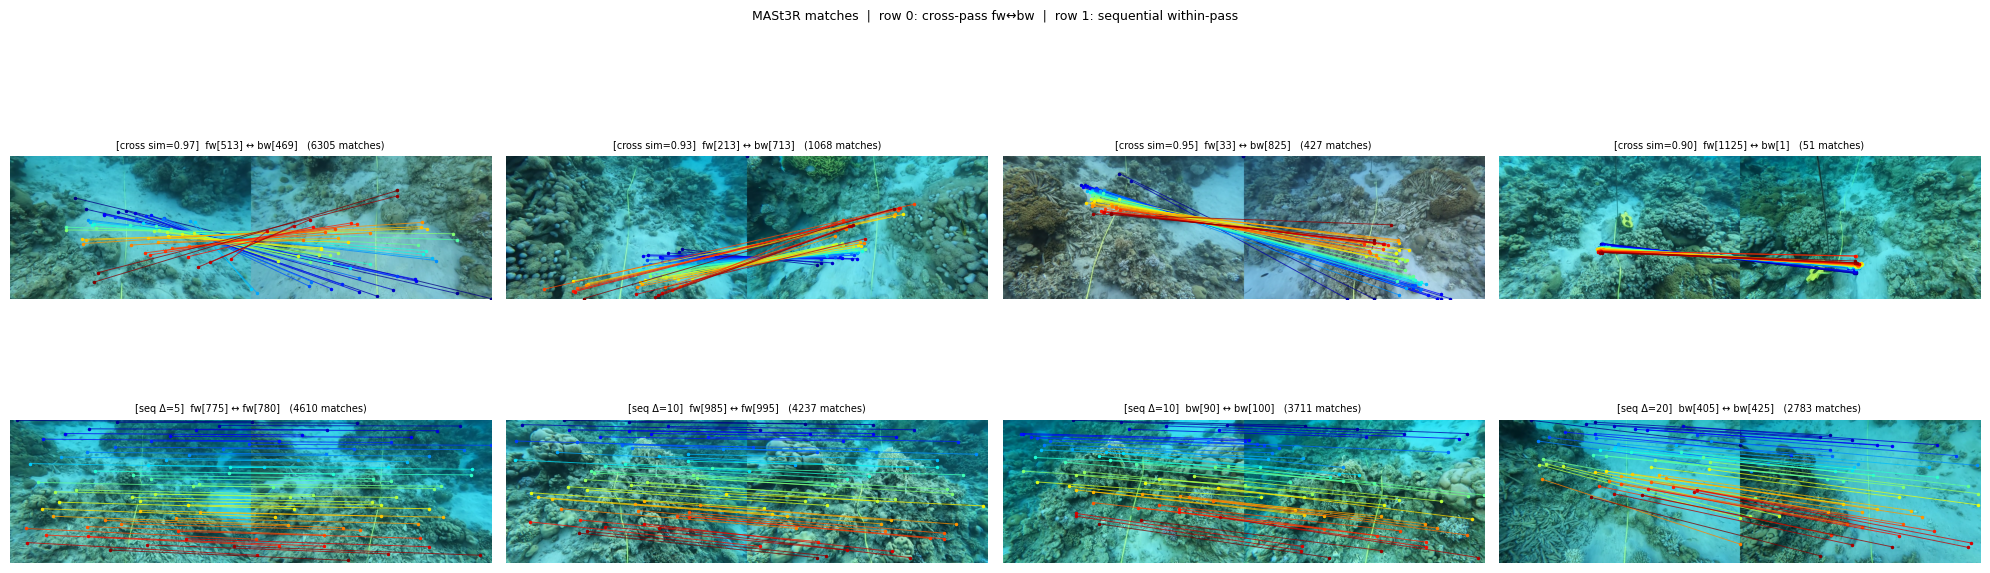


All 1834 pairs — min=1 median=3543 max=6305
  Cross-pass (210) — median=423 max=6305
  Sequential (1624)  — median=3711 max=4610


In [58]:
"""Visualise MASt3R matches for a sample of cross-pass and sequential pairs.

Matches are decoded directly from im_matches (ravel format) — no re-inference needed.
Left column: cross-pass fw↔bw pairs (the loop closures).
Right column: sequential pairs within each pass.
"""
import matplotlib.pyplot as _plt
import numpy as _np
from PIL import Image as _PIL

N_VIZ = 4  # pairs to show per row
N_LINES = 50  # match lines per pair

_cmap = _plt.get_cmap("jet")


def _decode_match_pair(gidx0, gidx1):
    """Decode a pair from im_matches into images + pixel coordinates."""
    ravel_arr = im_matches[(gidx0, gidx1)]  # [K, 2] — col0→gidx0, col1→gidx1

    H0, W0 = view_shape_cache[gidx0]
    H1, W1 = view_shape_cache[gidx1]

    y0, x0 = np.divmod(ravel_arr[:, 0].astype(np.int64), W0)
    y1, x1 = np.divmod(ravel_arr[:, 1].astype(np.int64), W1)

    is_bw0 = gidx0 >= N_fw
    is_bw1 = gidx1 >= N_fw
    li0 = gidx0 - N_fw if is_bw0 else gidx0
    li1 = gidx1 - N_fw if is_bw1 else gidx1

    # Load at MASt3R resolution for pixel-accurate display
    pil0 = _PIL.open(frames_bw[li0] if is_bw0 else frames_fw[li0]).convert("RGB")
    pil1 = _PIL.open(frames_bw[li1] if is_bw1 else frames_fw[li1]).convert("RGB")
    arr0 = _np.array(pil0.resize((W0, H0), _PIL.Resampling.LANCZOS))
    arr1 = _np.array(pil1.resize((W1, H1), _PIL.Resampling.LANCZOS))

    lbl0 = f"{'bw' if is_bw0 else 'fw'}[{li0}]"
    lbl1 = f"{'bw' if is_bw1 else 'fw'}[{li1}]"
    return arr0, arr1, x0.astype(int), y0.astype(int), x1.astype(int), y1.astype(int), lbl0, lbl1


def _plot_matches(ax, arr0, arr1, x0, y0, x1, y1, lbl0, lbl1, n_lines, tag):
    canvas_h = max(arr0.shape[0], arr1.shape[0])
    c0 = _np.pad(arr0, ((0, canvas_h - arr0.shape[0]), (0, 0), (0, 0)))
    c1 = _np.pad(arr1, ((0, canvas_h - arr1.shape[0]), (0, 0), (0, 0)))
    ax.imshow(_np.concatenate([c0, c1], axis=1))
    W0 = arr0.shape[1]

    step = max(1, len(x0) // n_lines)
    sel = _np.arange(0, len(x0), step)[:n_lines]
    for k, i in enumerate(sel):
        color = _cmap(k / max(len(sel) - 1, 1))
        ax.plot([x0[i], x1[i] + W0], [y0[i], y1[i]], "-", color=color, lw=0.7, alpha=0.75)
        ax.plot(x0[i], y0[i], ".", color=color, ms=3)
        ax.plot(x1[i] + W0, y1[i], ".", color=color, ms=3)

    ax.set_title(f"[{tag}]  {lbl0} ↔ {lbl1}   ({len(x0)} matches)", fontsize=7)
    ax.axis("off")


# ── Classify pairs ───────────────────────────────────────────────────
_all_pair_keys = [(g0, g1) for g0, g1 in im_matches.keys() if isinstance(g0, int)]
_cross = [(g0, g1) for g0, g1 in _all_pair_keys if g0 < N_fw <= g1]
_seq_fw = [(g0, g1) for g0, g1 in _all_pair_keys if g1 < N_fw]
_seq_bw = [(g0, g1) for g0, g1 in _all_pair_keys if g0 >= N_fw]
_seq = _seq_fw + _seq_bw

print(
    f"im_matches breakdown: {len(_cross)} cross-pass | {len(_seq_fw)} seq-fw | {len(_seq_bw)} seq-bw"
)

# Sample pairs: prefer high match counts for good visuals, spread across indices
_rng = _np.random.default_rng(7)


def _sample_spread(pairs, n):
    if not pairs:
        return []
    by_count = sorted(pairs, key=lambda p: len(im_matches[p]), reverse=True)
    pool = by_count[: max(n * 5, len(by_count))]
    # Evenly spaced across the sorted pool so we see variety in match count
    step = max(1, len(pool) // n)
    return pool[::step][:n]


_sample_cross = _sample_spread(_cross, N_VIZ)
_sample_seq = _sample_spread(_seq, N_VIZ)

n_rows = (1 if not _sample_cross else 1) + (1 if not _sample_seq else 1)
n_cols = N_VIZ
fig, axes = _plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=True)

for col, (g0, g1) in enumerate(_sample_cross):
    arr0, arr1, x0, y0, x1, y1, lbl0, lbl1 = _decode_match_pair(g0, g1)
    dino_sim = (
        float(sim[g0, g1 - N_fw]) if g0 < N_fw and (g1 - N_fw) < sim.shape[1] else float("nan")
    )
    tag = f"cross sim={dino_sim:.2f}"
    _plot_matches(axes[0, col], arr0, arr1, x0, y0, x1, y1, lbl0, lbl1, N_LINES, tag)

for col, (g0, g1) in enumerate(_sample_seq):
    arr0, arr1, x0, y0, x1, y1, lbl0, lbl1 = _decode_match_pair(g0, g1)
    gap = g1 - g0 if g1 < N_fw else (g1 - N_fw) - (g0 - N_fw)
    tag = f"seq Δ={gap}"
    _plot_matches(axes[1, col], arr0, arr1, x0, y0, x1, y1, lbl0, lbl1, N_LINES, tag)

_plt.suptitle(
    f"MASt3R matches  |  row 0: cross-pass fw↔bw  |  row 1: sequential within-pass",
    fontsize=9,
)
_plt.tight_layout()
_plt.show()

# ── Match count statistics ───────────────────────────────────────────
_counts = _np.array([len(im_matches[p]) for p in _all_pair_keys])
_counts_cross = _np.array([len(im_matches[p]) for p in _cross])
_counts_seq = _np.array([len(im_matches[p]) for p in _seq])
print(
    f"\nAll {len(_counts)} pairs — min={_counts.min()} median={int(_np.median(_counts))} max={_counts.max()}"
)
if len(_counts_cross):
    print(
        f"  Cross-pass ({len(_cross)}) — median={int(_np.median(_counts_cross))} max={_counts_cross.max()}"
    )
if len(_counts_seq):
    print(
        f"  Sequential ({len(_seq)})  — median={int(_np.median(_counts_seq))} max={_counts_seq.max()}"
    )

In [59]:
"""Populate two_view_geometries directly from matches (skip RANSAC verification).

This is the default MASt3R approach (skip_geometric_verification=True):
all confidence-filtered MASt3R matches are treated as geometric inliers
with config=2 (CALIBRATED). The EUCM→OPENCV_FISHEYE approximation is
accurate enough for triangulation/BA (<0.5px) but fails COLMAP's strict
E/F inlier ratio threshold (0.95) — so we bypass that classification step.

COLMAP's mapper still runs RANSAC internally during PnP image registration,
so outlier matches are handled at that stage.
"""
import sqlite3 as _sqlite3


def _pair_id(id1, id2):
    lo, hi = (id1, id2) if id1 < id2 else (id2, id1)
    return lo * 2147483647 + hi


_con = _sqlite3.connect(str(db_path))
_cur = _con.cursor()

n_exported = 0
for (gidx0, gidx1), ravel_matches in im_matches.items():
    if not isinstance(gidx0, int):
        continue

    idx_map0 = im_keypoints[gidx0].get("__idx_map__")
    idx_map1 = im_keypoints[gidx1].get("__idx_map__")
    if idx_map0 is None or idx_map1 is None:
        continue

    final_matches = []
    for r0, r1 in ravel_matches:
        if int(r0) in idx_map0 and int(r1) in idx_map1:
            final_matches.append([idx_map0[int(r0)], idx_map1[int(r1)]])
    if not final_matches:
        continue

    final_matches = np.array(final_matches, dtype=np.uint32)
    cimid0 = global_to_colmap_imid[gidx0]
    cimid1 = global_to_colmap_imid[gidx1]
    pid = _pair_id(cimid0, cimid1)

    # config=2 (CALIBRATED), identity E/F/H — same as MASt3R's default
    _E = np.eye(3, dtype=np.float64)
    _cur.execute(
        "INSERT OR REPLACE INTO two_view_geometries "
        "(pair_id, rows, cols, data, config, F, E, H) VALUES (?,?,?,?,?,?,?,?)",
        (
            pid,
            final_matches.shape[0],
            2,
            final_matches.tobytes(),
            2,
            _E.tobytes(),
            _E.tobytes(),
            _E.tobytes(),
        ),
    )
    n_exported += 1

_con.commit()
_con.close()

print(f"Exported {n_exported} pairs to two_view_geometries (config=2, skip verification)")
print(
    f"Total inlier matches: {sum(len(im_matches[k]) for k in im_matches if isinstance(k[0], int))}"
)

Exported 1834 pairs to two_view_geometries (config=2, skip verification)
Total inlier matches: 5710278


In [60]:
"""Incremental SfM: COLMAP builds a single reconstruction from verified matches.

Camera: PINHOLE with exact intrinsics from rectification — no distortion params.
All 4 params (fx, fy, cx, cy) are locked since they're known exactly.
"""
import pycolmap

sparse_dir = colmap_workdir / "sparse"
if sparse_dir.exists():
    import shutil

    shutil.rmtree(sparse_dir)
sparse_dir.mkdir(exist_ok=True)

maps = pycolmap.incremental_mapping(
    database_path=str(db_path),
    image_path=str(img_dir),  # rect_dir — rectified pinhole images
    output_path=str(sparse_dir),
    options=pycolmap.IncrementalPipelineOptions(
        multiple_models=False,
        ba_refine_focal_length=False,
        ba_refine_principal_point=False,
        ba_refine_extra_params=False,
    ),
)

if maps:
    reconstruction = maps[0]
    print(f"Registered: {reconstruction.num_reg_images()} / {len(global_to_colmap_imid)} images")
    print(f"3D points:  {reconstruction.num_points3D()}")
else:
    print("ERROR: incremental_mapping returned no reconstruction")

I20260224 15:47:05.512494 139942135850816 incremental_pipeline.cc:264] Loading database
I20260224 15:47:05.516916 139942135850816 database_cache.cc:67] Loading rigs...
I20260224 15:47:05.516952 139942135850816 database_cache.cc:77]  0 in 0.000s
I20260224 15:47:05.516966 139942135850816 database_cache.cc:85] Loading cameras...
I20260224 15:47:05.516994 139942135850816 database_cache.cc:103]  1 in 0.000s
I20260224 15:47:05.517001 139942135850816 database_cache.cc:111] Loading frames...
I20260224 15:47:05.517012 139942135850816 database_cache.cc:126]  0 in 0.000s
I20260224 15:47:05.517018 139942135850816 database_cache.cc:134] Loading matches...
I20260224 15:47:05.550714 139942135850816 database_cache.cc:139]  1834 in 0.034s
I20260224 15:47:05.550748 139942135850816 database_cache.cc:155] Loading images...
I20260224 15:47:05.664776 139942135850816 database_cache.cc:239]  814 in 0.114s (connected 605)
I20260224 15:47:05.664860 139942135850816 database_cache.cc:250] Building correspondence 

Registered: 479 / 814 images
3D points:  823511


## Validation and visualization

RECONSTRUCTION SUMMARY
Registered images: 479 / 814
  Forward:  287 / 542 (53%)
  Backward: 192 / 272 (71%)
3D points:  823511
Mean reproj error: 1.26 px

>>> CROSS-PASS LOOP CLOSURE: SUCCESS — both passes registered in same model


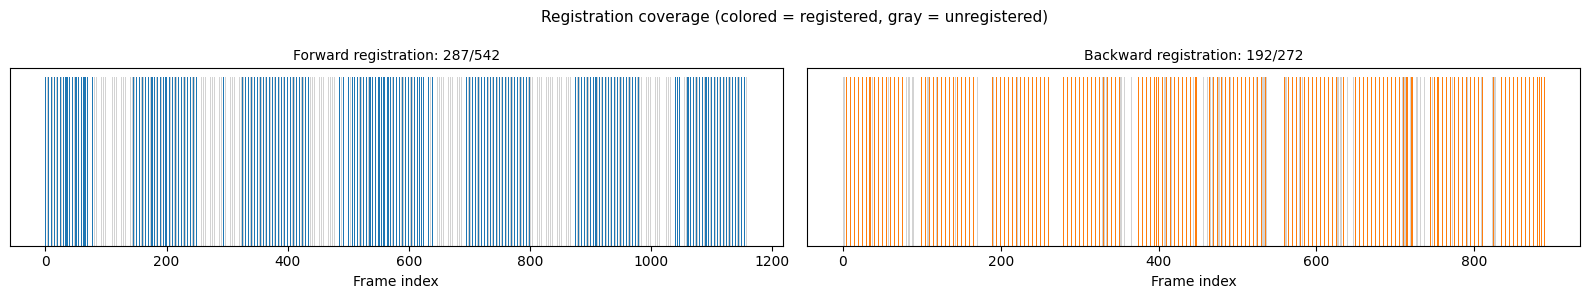

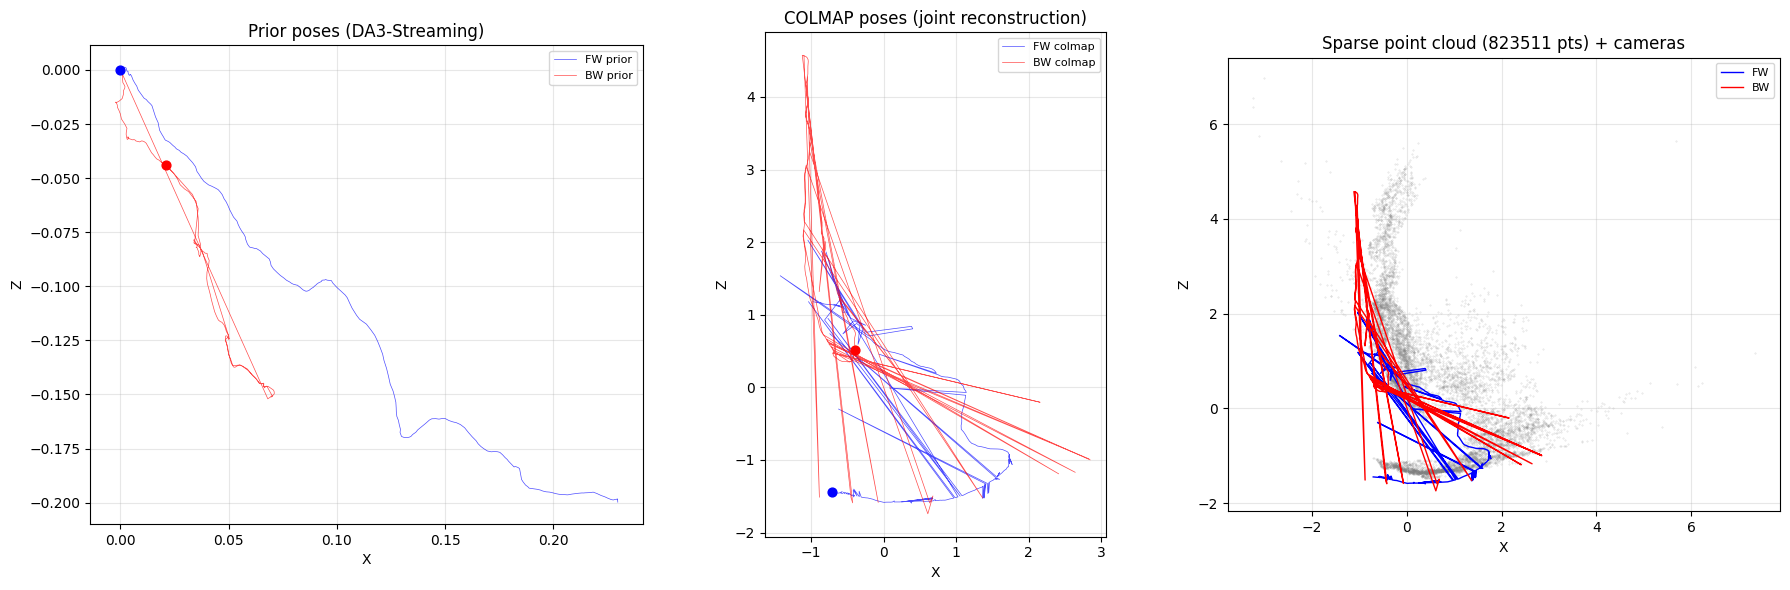

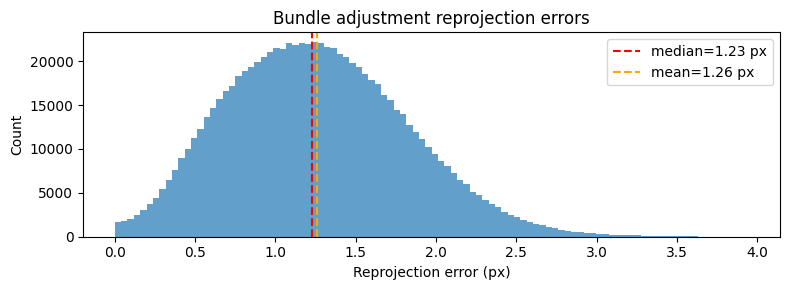


Reprojection errors: median=1.23 mean=1.26 p95=2.22 max=3.94 px


In [64]:
"""Verify reconstruction: registration breakdown, cross-pass connectivity, pose comparison."""
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as _Rot
from mpl_toolkits.mplot3d import Axes3D

# ── 1. Registration breakdown ────────────────────────────────────────
colmap_to_global = {v: k for k, v in global_to_colmap_imid.items()}

reg_fw, reg_bw, unreg_fw, unreg_bw = [], [], [], []
colmap_poses_c2w = {}  # global_idx → 4x4 C2W

for img_id, img in reconstruction.images.items():
    gidx = colmap_to_global.get(img_id)
    if gidx is None:
        continue
    # COLMAP stores W2C (qvec, tvec) → convert to C2W
    R_w2c = img.cam_from_world().rotation.matrix()
    t_w2c = img.cam_from_world().translation
    c2w = np.eye(4)
    c2w[:3, :3] = R_w2c.T
    c2w[:3, 3] = -R_w2c.T @ t_w2c
    colmap_poses_c2w[gidx] = c2w

    if gidx < N_fw:
        reg_fw.append(gidx)
    else:
        reg_bw.append(gidx - N_fw)

for gidx in global_to_colmap_imid:
    if gidx not in colmap_poses_c2w:
        if gidx < N_fw:
            unreg_fw.append(gidx)
        else:
            unreg_bw.append(gidx - N_fw)

print("=" * 60)
print("RECONSTRUCTION SUMMARY")
print("=" * 60)
print(f"Registered images: {reconstruction.num_reg_images()} / {len(global_to_colmap_imid)}")
print(
    f"  Forward:  {len(reg_fw)} / {len(used_fw_indices)} ({100 * len(reg_fw) / max(len(used_fw_indices), 1):.0f}%)"
)
print(
    f"  Backward: {len(reg_bw)} / {len(used_bw_indices)} ({100 * len(reg_bw) / max(len(used_bw_indices), 1):.0f}%)"
)
print(f"3D points:  {reconstruction.num_points3D()}")
print(f"Mean reproj error: {reconstruction.compute_mean_reprojection_error():.2f} px")

cross_pass_ok = len(reg_fw) > 0 and len(reg_bw) > 0
if cross_pass_ok:
    print(f"\n>>> CROSS-PASS LOOP CLOSURE: SUCCESS — both passes registered in same model")
else:
    print(
        f"\n>>> CROSS-PASS LOOP CLOSURE: FAILED — {'no fw' if not reg_fw else 'no bw'} images registered"
    )

# ── 2. Registration coverage plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 3))

# Forward
ax = axes[0]
reg_set_fw = set(reg_fw)
colors_fw = ["tab:blue" if i in reg_set_fw else "lightgray" for i in used_fw_indices]
ax.bar(used_fw_indices, [1] * len(used_fw_indices), color=colors_fw, width=1.0)
ax.set_title(f"Forward registration: {len(reg_fw)}/{len(used_fw_indices)}", fontsize=10)
ax.set_xlabel("Frame index")
ax.set_yticks([])

# Backward
ax = axes[1]
reg_set_bw = set(reg_bw)
colors_bw = ["tab:orange" if i in reg_set_bw else "lightgray" for i in used_bw_indices]
ax.bar(used_bw_indices, [1] * len(used_bw_indices), color=colors_bw, width=1.0)
ax.set_title(f"Backward registration: {len(reg_bw)}/{len(used_bw_indices)}", fontsize=10)
ax.set_xlabel("Frame index")
ax.set_yticks([])

plt.suptitle("Registration coverage (colored = registered, gray = unregistered)", fontsize=11)
plt.tight_layout()
plt.show()

# ── 3. Camera trajectory: COLMAP vs prior poses (top-down) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Extract positions
prior_fw_pos = np.array([poses_fw[i][:3, 3] for i in reg_fw]) if reg_fw else np.zeros((0, 3))
prior_bw_pos = np.array([poses_bw[i][:3, 3] for i in reg_bw]) if reg_bw else np.zeros((0, 3))
colmap_fw_pos = (
    np.array([colmap_poses_c2w[i][:3, 3] for i in reg_fw]) if reg_fw else np.zeros((0, 3))
)
colmap_bw_pos = (
    np.array([colmap_poses_c2w[N_fw + i][:3, 3] for i in reg_bw]) if reg_bw else np.zeros((0, 3))
)

# Plot 1: Prior poses (DA3)
ax = axes[0]
if len(prior_fw_pos):
    ax.plot(prior_fw_pos[:, 0], prior_fw_pos[:, 2], "b-", lw=0.5, alpha=0.7, label="FW prior")
    ax.scatter(prior_fw_pos[0, 0], prior_fw_pos[0, 2], c="b", s=40, marker="o", zorder=5)
if len(prior_bw_pos):
    ax.plot(prior_bw_pos[:, 0], prior_bw_pos[:, 2], "r-", lw=0.5, alpha=0.7, label="BW prior")
    ax.scatter(prior_bw_pos[0, 0], prior_bw_pos[0, 2], c="r", s=40, marker="o", zorder=5)
ax.set_title("Prior poses (DA3-Streaming)")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Plot 2: COLMAP poses
ax = axes[1]
if len(colmap_fw_pos):
    ax.plot(colmap_fw_pos[:, 0], colmap_fw_pos[:, 2], "b-", lw=0.5, alpha=0.7, label="FW colmap")
    ax.scatter(colmap_fw_pos[0, 0], colmap_fw_pos[0, 2], c="b", s=40, marker="o", zorder=5)
if len(colmap_bw_pos):
    ax.plot(colmap_bw_pos[:, 0], colmap_bw_pos[:, 2], "r-", lw=0.5, alpha=0.7, label="BW colmap")
    ax.scatter(colmap_bw_pos[0, 0], colmap_bw_pos[0, 2], c="r", s=40, marker="o", zorder=5)
ax.set_title("COLMAP poses (joint reconstruction)")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Plot 3: 3D sparse point cloud (top-down)
ax = axes[2]
pts3d = np.array([p.xyz for p in reconstruction.points3D.values()])
if len(pts3d) > 10000:
    _idx = np.random.choice(len(pts3d), 10000, replace=False)
    pts3d_sub = pts3d[_idx]
else:
    pts3d_sub = pts3d
ax.scatter(pts3d_sub[:, 0], pts3d_sub[:, 2], s=0.1, c="gray", alpha=0.3)
if len(colmap_fw_pos):
    ax.plot(colmap_fw_pos[:, 0], colmap_fw_pos[:, 2], "b-", lw=1, label="FW")
if len(colmap_bw_pos):
    ax.plot(colmap_bw_pos[:, 0], colmap_bw_pos[:, 2], "r-", lw=1, label="BW")
ax.set_title(f"Sparse point cloud ({len(pts3d)} pts) + cameras")
ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.legend(fontsize=8)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4. BA residual statistics ────────────────────────────────────────
errors = []
for p in reconstruction.points3D.values():
    errors.append(p.error)
errors = np.array(errors)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(errors, bins=100, range=(0, min(10, errors.max())), edgecolor="none", alpha=0.7)
ax.axvline(np.median(errors), color="red", ls="--", label=f"median={np.median(errors):.2f} px")
ax.axvline(np.mean(errors), color="orange", ls="--", label=f"mean={np.mean(errors):.2f} px")
ax.set_xlabel("Reprojection error (px)")
ax.set_ylabel("Count")
ax.set_title("Bundle adjustment reprojection errors")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"\nReprojection errors: median={np.median(errors):.2f} mean={np.mean(errors):.2f} "
    f"p95={np.percentile(errors, 95):.2f} max={errors.max():.2f} px"
)

In [8]:
import pycolmap

rec = pycolmap.Reconstruction(str(colmap_workdir / "sparse" / "0"))

n_cross = 0
n_total = 0
for pt in rec.points3D.values():
    has_fw = any(rec.images[e.image_id].name.startswith("fwd") for e in pt.track.elements)
    has_bw = any(rec.images[e.image_id].name.startswith("bwd") for e in pt.track.elements)
    if has_fw and has_bw:
        n_cross += 1
        break
    n_total += 1

print(
    f"3D points with BOTH fw+bw observations: {n_cross} / {n_total} ({100 * n_cross / n_total:.1f}%)"
)

3D points with BOTH fw+bw observations: 1 / 59 (1.7%)


In [13]:
import sqlite3
import numpy as np

db_path = colmap_workdir / "colmap.db"

con = sqlite3.connect(str(db_path))

# Get image_id → name mapping
id_to_name = dict(con.execute("SELECT image_id, name FROM images").fetchall())

# Check two_view_geometries inlier counts by pair type
cross_inliers = []
seq_fw_inliers = []
seq_bw_inliers = []

for row in con.execute("SELECT pair_id, rows, config FROM two_view_geometries"):
    pair_id, n_inliers, config = row
    id2 = pair_id % 2147483647
    id1 = pair_id // 2147483647
    name1 = id_to_name.get(id1, "?")
    name2 = id_to_name.get(id2, "?")

    is_fw1 = name1.startswith("fwd")
    is_fw2 = name2.startswith("fwd")

    if is_fw1 != is_fw2:  # cross-pass
        cross_inliers.append(n_inliers)
    elif is_fw1:  # both fw
        seq_fw_inliers.append(n_inliers)
    else:  # both bw
        seq_bw_inliers.append(n_inliers)

con.close()

for label, arr in [
    ("Cross-pass", cross_inliers),
    ("Seq fw", seq_fw_inliers),
    ("Seq bw", seq_bw_inliers),
]:
    a = np.array(arr)
    if len(a):
        print(
            f"{label:12s}: n={len(a):4d}  median={np.median(a):.0f}  "
            f"mean={np.mean(a):.0f}  min={a.min()}  max={a.max()}  "
            f"<50 inliers: {(a < 50).sum()}"
        )
    else:
        print(f"{label:12s}: NO PAIRS")

Cross-pass  : n= 210  median=424  mean=1048  min=1  max=6305  <50 inliers: 53
Seq fw      : n= 921  median=3870  mean=3566  min=1124  max=4610  <50 inliers: 0
Seq bw      : n= 703  median=3456  mean=3138  min=37  max=4468  <50 inliers: 1


In [12]:
from collections import defaultdict, deque

# Build adjacency graph from shared 3D point observations
adj = defaultdict(set)
for pt in rec.points3D.values():
    img_ids = [e.image_id for e in pt.track.elements]
    for a in img_ids:
        for b in img_ids:
            if a != b:
                adj[a].add(b)

# BFS to find connected components
visited = set()
components = []
for start in rec.images:
    if start in visited:
        continue
    comp = set()
    queue = deque([start])
    while queue:
        node = queue.popleft()
        if node in comp:
            continue
        comp.add(node)
        visited.add(node)
        for nb in adj.get(node, []):
            if nb not in comp:
                queue.append(nb)
    components.append(comp)

print(f"Connected components: {len(components)}")
for i, comp in enumerate(sorted(components, key=len, reverse=True)):
    n_fw = sum(1 for c in comp if rec.images[c].name.startswith("fwd"))
    n_bw = len(comp) - n_fw
    print(f"  Component {i}: {len(comp)} images ({n_fw} fw, {n_bw} bw)")

Connected components: 1
  Component 0: 479 images (287 fw, 192 bw)


### Diagnosis

**The two passes are effectively decoupled.** Only 1 out of 59 3D points (1.7%) is observed by both fw and bw cameras. Despite being in a single connected component, the two trajectories are held together by an almost invisible thread — the connection is topological (they share a graph path) but not geometric (they don't share meaningful 3D structure).

**Cross-pass matches exist but are weak relative to sequential.** 210 cross-pass pairs survived geometric verification with median 424 inliers — that's not terrible in isolation, but compared to sequential pairs (median 3870 fw, 3456 bw), they're 8-9x weaker. COLMAP's bundle adjustment is dominated by the sequential signal, and the cross-pass matches contribute almost no triangulated points.

**The match graph has no break, but has a bottleneck.** 1 connected component with 479 images, yet only 1 shared 3D point between passes. The fw and bw subgraphs are each internally well-connected (strong sequential chains), but the bridge between them is paper-thin. COLMAP treats them as one model but can't rigidly constrain one relative to the other.

**The sandy area breaks sequential rigidity.** Low-texture regions mean MASt3R matches at offsets 5+ fail, creating holes in the sequential chain. Without adjacent-frame pairs (offsets 1-2), there's nothing to carry the trajectory through these gaps, so it folds.

### Why the two U-shapes form

What likely happened during COLMAP's incremental mapping:

1. COLMAP built the fw trajectory first (strong sequential chain), but it drifted/folded over the sandy gap
2. It then registered bw images using the few cross-pass matches as anchors, but since those anchors barely triangulate any shared 3D points, the bw trajectory was placed roughly nearby but not rigidly constrained
3. Bundle adjustment couldn't fix the relative alignment because there are almost no shared 3D points pulling the two passes together
4. Result: two independently-drifted trajectories (U-shapes) living in the same coordinate frame but not geometrically coupled

### The two things that need fixing

1. **Sequential rigidity** — add dense short-range pairs (offsets 1, 2, 3) so the trajectory can't fold over the sandy area
2. **Cross-pass coupling** — the 210 cross-pass pairs produce matches that pass geometric verification but don't result in shared 3D points; this needs investigation into *why* triangulation fails for cross-pass pairs (likely because the baseline/pose accuracy between passes is too poor for COLMAP to triangulate confidently)